# Machine Learning Final Project - Phase 2 (Clustering with K-Means)

This notebook performs unsupervised clustering on a new dataset suitable for clustering (Wine dataset from scikit-learn).

## 1. Imports and Configuration

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

print('Imports loaded successfully.')

Imports loaded successfully.


## 2. Data Understanding
Load a new dataset for unsupervised learning and inspect structure.

In [35]:
df = pd.read_csv("wine.csv")

# Drop target/label columns if present (unsupervised learning)
target_cols = [c for c in df.columns if c.strip().lower() in {"class", "target", "label"}]
if target_cols:
    df = df.drop(columns=target_cols)

# Keep only numeric columns for clustering
X_df = df.select_dtypes(include=[np.number]).copy()
feature_cols = X_df.columns.tolist()

print(f'Dataset shape: {X_df.shape[0]} rows x {X_df.shape[1]} columns')
display(X_df.head())

print('Data types:')
display(X_df.dtypes)

Dataset shape: 178 rows x 13 columns


,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Data types:


Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Proline                           int64
dtype: object

## 3. Data Exploration
Review summary statistics and relationships among features.

In [36]:
display(X_df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83
Malic acid,178.0,2.336,1.117,0.74,1.602,1.865,3.082,5.80
Ash,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23
Alcalinity of ash,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00
Magnesium,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00
Total phenols,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88
Flavanoids,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08
Nonflavanoid phenols,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66
Proanthocyanins,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58
Color intensity,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00


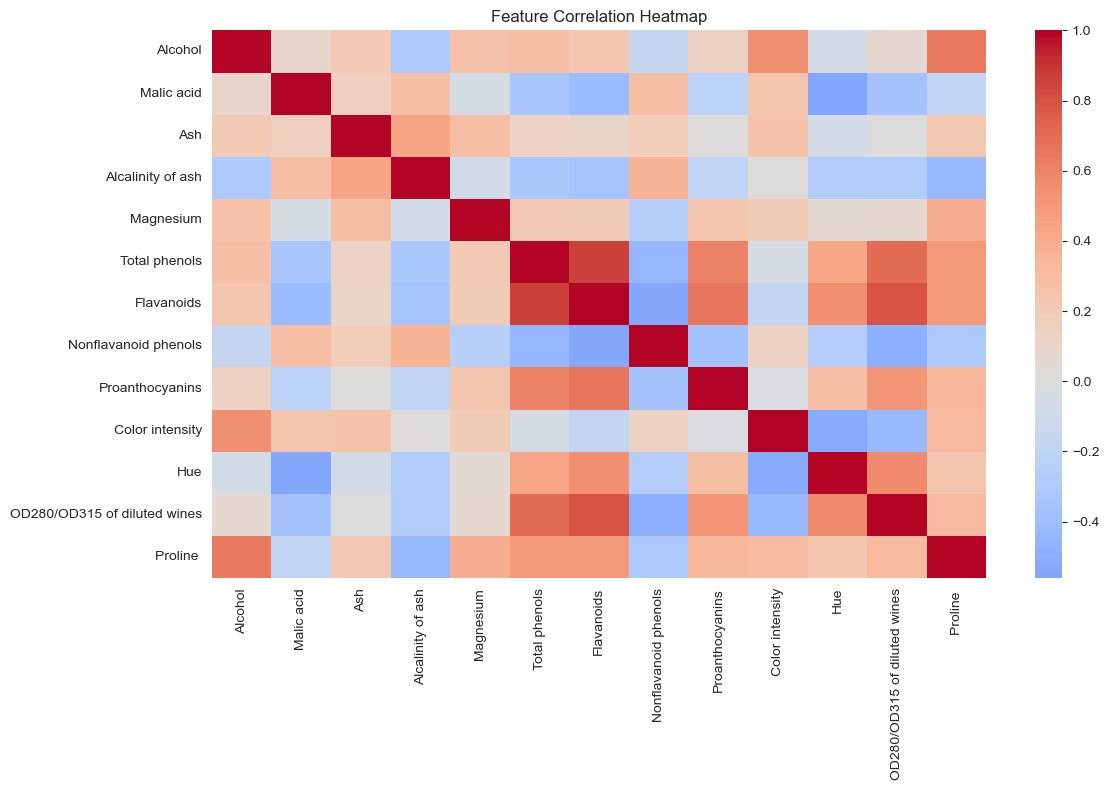

In [37]:
plt.figure(figsize=(12, 8))
corr = X_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Data Quality Checks
Check missing values and duplicates, then clean if required.

In [38]:
print('Missing values per column:')
display(X_df.isnull().sum())

dup_count = X_df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

# Handle missing values if present
if X_df.isnull().sum().sum() > 0:
    X_df = X_df.fillna(X_df.median(numeric_only=True))

# Remove duplicates if present
if dup_count > 0:
    X_df = X_df.drop_duplicates().reset_index(drop=True)

print(f'Cleaned dataset shape: {X_df.shape}')

Missing values per column:


Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
dtype: int64

Duplicate rows: 0
Cleaned dataset shape: (178, 13)


## 5. Feature Scaling
Scale features because K-Means is distance-based and sensitive to feature magnitude.

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

print('Scaling complete.')
print(f'Scaled matrix shape: {X_scaled.shape}')

Scaling complete.
Scaled matrix shape: (178, 13)


## 6. Elbow Method
Use inertia to inspect candidate values of K.

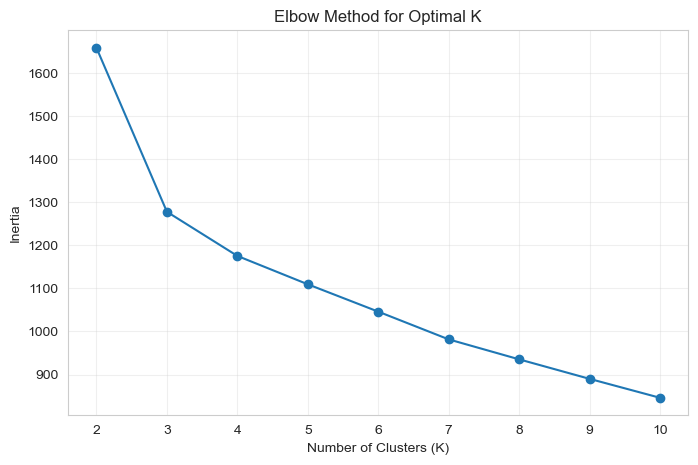

In [40]:
k_values = list(range(2, 11))
inertias = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

## 7. Silhouette Analysis
Compute silhouette score across K values to measure cluster quality.

,K,SilhouetteScore
0,2,0.2593
1,3,0.2849
2,4,0.2602
3,5,0.2016
4,6,0.2372
5,7,0.2036
6,8,0.1570
7,9,0.1499
8,10,0.1436


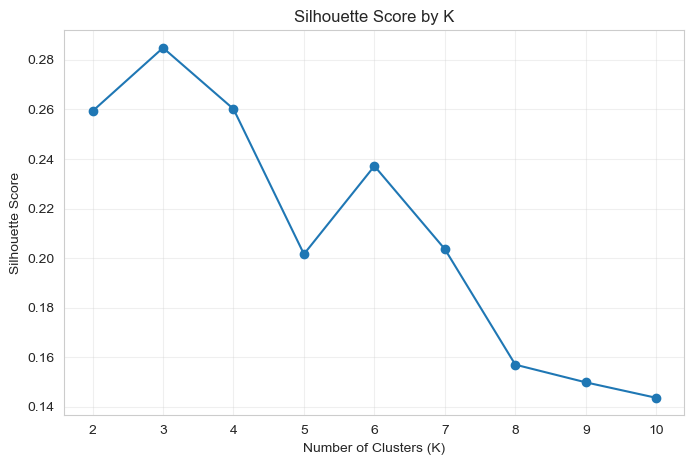

In [41]:
silhouette_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

sil_df = pd.DataFrame({'K': k_values, 'SilhouetteScore': silhouette_scores})
display(sil_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

## 8. Final K-Means Model
Select K using silhouette (supported by elbow trend), fit final model, and assign cluster labels.

In [42]:
best_k = sil_df.loc[sil_df['SilhouetteScore'].idxmax(), 'K']
best_k = int(best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

clustered_df = X_df.copy()
clustered_df['Cluster'] = cluster_labels

final_silhouette = silhouette_score(X_scaled, cluster_labels)

print(f'Selected K: {best_k}')
print(f'Final silhouette score: {final_silhouette:.4f}')
display(clustered_df['Cluster'].value_counts().sort_index())

Selected K: 3
Final silhouette score: 0.2849


Cluster
0    65
1    51
2    62
Name: count, dtype: int64

## 9. Cluster Visualization with PCA
Use PCA to project high-dimensional data into 2D for visualization.

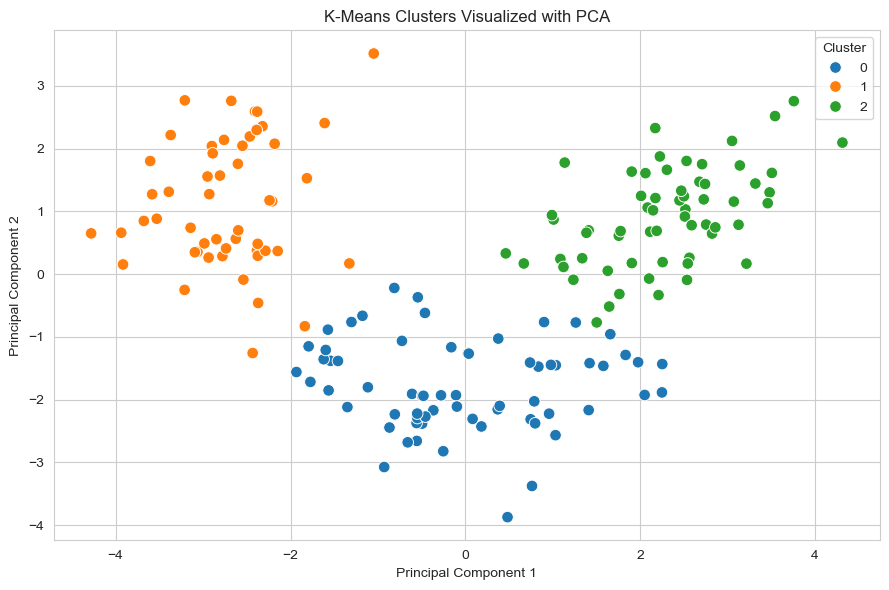

In [43]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

viz_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
viz_df['Cluster'] = cluster_labels

plt.figure(figsize=(9, 6))
sns.scatterplot(data=viz_df, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=70)
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 10. Cluster Interpretation
Profile clusters by feature means to explain how groups differ.

In [44]:
cluster_profile = clustered_df.groupby('Cluster').mean().round(3)
display(cluster_profile)

,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
Cluster,,,,,,,,,,,,,
0,12.251,1.897,2.231,20.063,92.738,2.248,2.050,0.358,1.624,2.973,1.063,2.803,510.169
1,13.134,3.307,2.418,21.241,98.667,1.684,0.819,0.452,1.146,7.235,0.692,1.697,619.059
2,13.677,1.998,2.466,17.463,107.968,2.848,3.003,0.292,1.922,5.454,1.065,3.163,1100.226


## 11. Final Conclusion
- The selected number of clusters is based on the best silhouette score and supported by elbow analysis.
- A higher silhouette score indicates better-separated and more compact clusters.
- PCA visualization helps verify that clusters are reasonably distinct in reduced space.

Overall, clustering quality is considered good when silhouette is comparatively high and visual overlap is limited.